# Importing the required modules

In [130]:
#Make sure you are in the root folder quant_project when doing this command, if not do: 
# %cd quant_project
%pwd

'/Users/luca0808/quant_project'

In [123]:
#Ignoring the warning will not cause any trouble
%cd ..

/Users


In [124]:
%pwd

'/Users'

In [131]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor

# Adding some important economic instruments which we will use  later on

# T-Statistic with the null hypothesis $H_0: \mathbb{E}[X_i] = 0$, where $X_{i}$ represents the PnL of trade $i$. 

In [133]:
def pnl_t_stat(pnl_vector):
    
    sample_mean_pnl = pnl_vector[pnl_vector != 0].mean()
    std_pnl_per_trade = np.std(pnl_vector[pnl_vector != 0], ddof=1)

    n = len(pnl_vector[pnl_vector != 0])   #nr of observations

    se = std_pnl_per_trade / np.sqrt(n)

    return sample_mean_pnl/se

# Maximum Drawdown

In [134]:
def max_drawdown(pnl_vector):

    cumulative = pnl_vector.cumsum()
    running_max = np.maximum.accumulate(cumulative)

    drawdown = cumulative - running_max

    return drawdown.min()

# 1. Data Analysis

# We start off by loading the dataset and making a copy off of it

In [135]:
!pwd

/Users/luca0808/quant_project


In [136]:
df = pd.read_pickle("data/synthetic_dataset_studycase.pkl")
df_used = df.copy()

In [137]:
df

,imb_price_pos,imb_price_neg,nuclear_real,fossil_gas_real,imb_volume,afrr_down,afrr_up,mfrr_down,mfrr_up,load_real,load_fcst,solar_fcst,wind_fcst,solar_real,wind_real,ID_QH_Last,ID_QH_VWAP
2022-07-01 00:00:00+00:00,714.026930,947.901755,1154.275398,1463.052136,-12.388922,0.054061,4.305869,5.232816,11.595919,5974.624957,5962.500663,0.0,907.857680,16.033193,903.875245,707.486935,718.186736
2022-07-01 00:15:00+00:00,527.359710,936.546242,1111.959987,1416.058702,50.853690,19.283418,2.435461,16.860183,16.366907,5717.460903,5710.734998,0.0,752.202273,0.000000,599.398022,739.741788,644.400296
2022-07-01 00:30:00+00:00,589.228552,428.261093,1103.246071,1558.212105,125.636142,24.174811,1.374872,46.855757,77.215045,5784.610912,5801.284348,0.0,849.798098,0.000000,680.563308,458.036299,509.192256
2022-07-01 00:45:00+00:00,665.040841,909.269496,1111.651800,1526.749391,137.589397,29.729701,15.099541,55.080789,53.696199,5851.334070,5846.551179,0.0,723.955105,47.128684,661.491909,553.247981,515.148727
2022-07-01 01:00:00+00:00,613.097145,314.410993,1111.960270,1275.041881,125.268085,42.106330,11.230469,40.338683,21.554716,5426.986023,5490.177936,0.0,745.282001,0.000000,655.505373,543.826653,496.902239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 22:45:00+00:00,252.253838,810.923164,1372.548628,1666.144990,160.825964,12.928807,17.584091,46.118529,14.294197,6630.904193,6570.051912,0.0,747.807133,0.000000,568.467447,655.112152,687.525607
2025-01-01 23:00:00+00:00,294.316024,536.455730,1380.536274,1631.480128,103.780387,26.636512,22.373053,32.880166,53.314169,6701.768853,6613.020138,0.0,670.385794,0.000000,542.181180,679.278479,702.285558
2025-01-01 23:15:00+00:00,919.453994,795.678546,1377.073744,1786.455951,211.091845,28.129863,24.600798,92.127606,22.255062,6687.729244,6644.253361,0.0,803.513024,0.000000,667.736239,732.118944,714.029066
2025-01-01 23:30:00+00:00,1217.361727,583.188098,1383.724151,1659.620790,99.179048,51.705174,4.647494,32.783544,2.755304,6477.595913,6467.398875,0.0,760.588311,10.817417,676.700347,632.824367,579.704687


# We do a quick sanity check that the data is well ordered

In [138]:
df_used.index.is_monotonic_increasing

True

# Since energy prices are affected by the hours and weekdays, it is a good idea to cyclically encode data like 15, 60 minute increments and the weekdays. We will do that with sinus and cosinus encoding.

In [139]:
df_used["15_min_incr_sin"] = np.sin(2*np.pi*df.index.minute/4)
df_used["15_min_incr_cos"] = np.cos(2*np.pi*df.index.minute/4)
df_used["hour_incr_sin"] = np.sin(2*np.pi*df.index.hour/24)
df_used["hour_incr_cos"] = np.cos(2*np.pi*df.index.hour/24)
df_used["weekday_incr_sin"] = np.sin(2*np.pi*df.index.hour/7)
df_used["weekday_incr_cos"] = np.cos(2*np.pi*df.index.hour/7)

# One of the first goals is to decide what our target values are: The spreads between imbalance and the intraday prices. 

# Mathematically speaking, it would make sense to choose the VWAP prices, as they offer a smoothing property which the "last intraday price column" does not have.

In [140]:
df_used["spread_buy_side"] = df_used["imb_price_pos"] - df_used["ID_QH_VWAP"]
df_used["spread_sell_side"] = df_used["ID_QH_VWAP"] - df_used["imb_price_neg"]

# We proceed on deleting the "ID_QH_VWAP" column from our dataframe.

In [141]:
del df_used["ID_QH_Last"]

# In the next step we would decide if the arbitrage strategy would be one-sided (either buy  or sell side) or two-sided (including both). We will do that by first answering two questions:
#    1. How often is each spread profitable?
#    2. On average, what is the profit for each positive spread? 

# For the first question, we have: 

In [142]:
Mean_spread_buy = (df_used["spread_buy_side"] > 0).mean() 
Mean_spread_sell = (df_used["spread_sell_side"] > 0).mean()

In [143]:
print(f"The frequency of spread_buy_side being positive is: {Mean_spread_buy}")
print(f"The frequency of spread_sell_side being positive is: {Mean_spread_sell}")


The frequency of spread_buy_side being positive is: 0.6990583846976142
The frequency of spread_sell_side being positive is: 0.38864375554393066


# Note that these are not mutually exclusive events, as both can be simultaneously positive.

# As for the second question, we have:

In [144]:
Avg_profit_buy_opportunity = df_used.loc[df_used["spread_buy_side"] > 0, "spread_buy_side"].mean()
Avg_profit_sell_opportunity = df_used.loc[df_used["spread_sell_side"] > 0, "spread_sell_side"].mean()

In [145]:
print(f"The average profit from a positive buy_side is: ",  Avg_profit_buy_opportunity)
print(f"The average profit from a positive sell_side is: ", Avg_profit_sell_opportunity)

The average profit from a positive buy_side is:  295.3967742364366
The average profit from a positive sell_side is:  143.66033127174893


# Having seen that both sides offer the same amount of upside with a moderate discrepancy between their frequency, it is reasonable to decide on including both to our model.

# Other discrepancies we might consider would be the ones between the real and the forecasted weather/load events.

In [146]:
df_used["load_error"] = df_used["load_real"] - df_used["load_fcst"]
df_used["wind_error"] = df_used["wind_real"] - df_used["wind_fcst"]
df_used["solar_error"] = df_used["solar_real"] - df_used["solar_fcst"]

# Before curating our dataset, we will also consider adding useful features derived from the aFRR and mFRR data columns. Namely, we will consider:
   # 1. The Total Reserves
   # This feature helps us to decide whether the TSO is struggling to balance supply or demand.
   # 2. The Net Balancing Direciton
   # This feature helps us decide whether there is a system deficit (when the value is positive) or a deficit (when the value is negative).
   # 3. The Reserve Ramping
   # This feature determines the fluctuations of the system which in turn give use potential arbitrage opportunities.

In [147]:
#The Total Resverves 
df_used["total_reserve"] = df_used["afrr_up"] + df_used["afrr_down"] + df_used["mfrr_up"] + df_used["mfrr_down"]
#The Net Balancing Direction
df_used["net_reserve"] = df_used["afrr_up"] - df_used["afrr_down"] + df_used["mfrr_up"] - df_used["mfrr_down"]
#The Reserve Ramping
df_used["reserve_ramping"] = df_used["net_reserve"].diff()

In [148]:
#Adding an additional volume-related feature:
df_used["vwap_jump"] = df_used["ID_QH_VWAP"].diff()
df["vwap_mean_1h"] = df["ID_QH_VWAP"].rolling(4).mean()

In [149]:
df_used["imb_volume_jump"] =  df_used["imb_volume"].diff()

# Keeping in mind the time constraints of both the 60 minute intraday decision before delivery and the 25 minute lag from the observed data, we will use a lag of 80 minutes to our dataset by invoking the ".shift()" command (where necessary).

In [150]:
df_used.columns

Index(['imb_price_pos', 'imb_price_neg', 'nuclear_real', 'fossil_gas_real',
       'imb_volume', 'afrr_down', 'afrr_up', 'mfrr_down', 'mfrr_up',
       'load_real', 'load_fcst', 'solar_fcst', 'wind_fcst', 'solar_real',
       'wind_real', 'ID_QH_VWAP', '15_min_incr_sin', '15_min_incr_cos',
       'hour_incr_sin', 'hour_incr_cos', 'weekday_incr_sin',
       'weekday_incr_cos', 'spread_buy_side', 'spread_sell_side', 'load_error',
       'wind_error', 'solar_error', 'total_reserve', 'net_reserve',
       'reserve_ramping', 'vwap_jump', 'imb_volume_jump'],
      dtype='object')

In [151]:
to_be_shifted =[
    "imb_volume",
    "imb_volume_jump",
    "vwap_jump",
    "ID_QH_VWAP",
    "load_error",
    "wind_error",
    "solar_error",
    "total_reserve",
    "net_reserve",
    "reserve_ramping",
]

In [152]:
for col in to_be_shifted:
    df_used[f"{col}_lag6"] = df_used[col].shift(6)

# 2. Data curation 

# We are now ready to get rid of the unshifted columns and create the feature and the target sample

In [153]:
feature_columns = []
for elem in to_be_shifted:
    feature_columns.append(f"{elem}_lag6")
    
feature_columns += [
        "15_min_incr_sin",
        "15_min_incr_cos",
        "hour_incr_sin",
        "hour_incr_cos",
        "weekday_incr_sin",
        "weekday_incr_cos"]


In [154]:
feature_columns

['imb_volume_lag6',
 'imb_volume_jump_lag6',
 'vwap_jump_lag6',
 'ID_QH_VWAP_lag6',
 'load_error_lag6',
 'wind_error_lag6',
 'solar_error_lag6',
 'total_reserve_lag6',
 'net_reserve_lag6',
 'reserve_ramping_lag6',
 '15_min_incr_sin',
 '15_min_incr_cos',
 'hour_incr_sin',
 'hour_incr_cos',
 'weekday_incr_sin',
 'weekday_incr_cos']

In [155]:
# Getting rid of the NaN values
df_used = df_used.dropna()

In [156]:
features = df_used[feature_columns]
target_buy = df_used["spread_buy_side"]
target_sell = df_used["spread_sell_side"]

# Filtering the dataset based on the July month.

In [157]:
train = df_used[df_used.index < "2024-07-01"]
test = df_used[df_used.index >= "2024-07-01"]

# The training dataset

In [158]:
X_train = train[feature_columns]
X_test = test[feature_columns]

# The target datasets

In [159]:
y_buy_train = train["spread_buy_side"]
y_buy_test = test["spread_buy_side"]

y_sell_train = train["spread_sell_side"]
y_sell_test = test["spread_sell_side"]

# 3. Training and Testing Models

# Before getting to train our models, we will implement the threshold function, whose role is to maximize the PNL and reduce noisy trades. We will derive the best threshold by using the training data. The output will be the best_buy_threshold, the best_sell_threshold and the pnl from the training dataset.

In [160]:
def optimize_buy_sell_thresholds_and_pnl(
    pred_buy,
    pred_sell,
    real_buy,
    real_sell,
    volume=10,
    n_steps=100
):
    buy_thresholds = np.linspace(0, np.max(pred_buy), n_steps)
    sell_thresholds = np.linspace(0, np.max(pred_sell), n_steps)

    best_buy_threshold = None
    best_sell_threshold = None
    best_pnl = -np.inf

    for thr_buy in buy_thresholds:
        for thr_sell in sell_thresholds:
            buy_edge = pred_buy - thr_buy
            sell_edge = pred_sell - thr_sell

            pnl = np.zeros(len(pred_buy))

            buy_only = (buy_edge > 0) & (sell_edge <= 0)
            sell_only = (sell_edge > 0) & (buy_edge <= 0)
            both = (buy_edge > 0) & (sell_edge > 0)

            choose_buy = both & (buy_edge >= sell_edge)
            choose_sell = both & (sell_edge > buy_edge)

            pnl[buy_only] = volume * real_buy[buy_only]
            pnl[sell_only] = volume * real_sell[sell_only]
            pnl[choose_buy] = volume * real_buy[choose_buy]
            pnl[choose_sell] = volume * real_sell[choose_sell]

            total_pnl = pnl.sum()

            if total_pnl > best_pnl:
                best_pnl = total_pnl
                best_buy_threshold = thr_buy
                best_sell_threshold = thr_sell

    return best_buy_threshold, best_sell_threshold, best_pnl

In [161]:
def compute_strategy_pnl(pred_buy, pred_sell, real_buy, real_sell,
                         thr_buy, thr_sell, volume=10):
    buy_edge = pred_buy - thr_buy
    sell_edge = pred_sell - thr_sell

    buy_only = (buy_edge > 0) & (sell_edge <= 0)
    sell_only = (sell_edge > 0) & (buy_edge <= 0)
    both = (buy_edge > 0) & (sell_edge > 0)

    choose_buy = both & (buy_edge >= sell_edge)
    choose_sell = both & (sell_edge > buy_edge)

    pnl = np.zeros(len(pred_buy))

    pnl[buy_only] = volume * real_buy[buy_only]
    pnl[sell_only] = volume * real_sell[sell_only]
    pnl[choose_buy] = volume * real_buy[choose_buy]
    pnl[choose_sell] = volume * real_sell[choose_sell]

    decision = np.full(len(pred_buy), "no_trade", dtype=object)
    decision[buy_only] = "buy"
    decision[sell_only] = "sell"
    decision[choose_buy] = "buy"
    decision[choose_sell] = "sell"

    total_pnl = pnl.sum()
    n_buy = np.sum(decision == "buy")
    n_sell = np.sum(decision == "sell")
    n_trades = n_buy + n_sell
    avg_pnl_per_trade = total_pnl / n_trades if n_trades > 0 else 0.0

    return {
        "pnl_vector": pnl,
        "decision": decision,
        "total_pnl": total_pnl,
        "n_buy": n_buy,
        "n_sell": n_sell,
        "n_trades": n_trades,
        "avg_pnl_per_trade": avg_pnl_per_trade,
        "std_pnl_per_trade": np.std(pnl[pnl!=0], ddof = 1),
        "max_drawdown": max_drawdown(pnl),
        "t-statistic" : pnl_t_stat(pnl)
    }

# Additionally, we would want to have a notion of a perfect PnL which we would add as one of our benchmarks for the models profitability. This perfect PnL needs to be treated with a grain of salt. It is analogous to God playing in the Stock market - He always knows whether He should buy, sell or place no trade at all. 

In [162]:
perfect_pnl_vector = 10 * np.maximum.reduce([
    y_buy_test.values,     # accounts for the buying positions
    y_sell_test.values,    # accounts for the selling positions
    np.zeros(len(y_buy_test))  # accounts for when we should do nothing, given unfavorable buy/sell positions
])
perfect_pnl = perfect_pnl_vector.sum()

# ------------------------------------------------------------------------------

# Optional Section: The following section is an important and fun insight into the consequences of trying to trade simply based on luck. It can be skipped.

# Now, we would like to take the opposite approach. A benchmark which should always be surpassed would be one in which a complete lunatic would place equal chances to "buy", "sell", "no_trade".

In [163]:
def random_strategy(y_buy_test, y_sell_test, volume = 10, seed = 42):
    rng = np.random.default_rng(seed)
    random_side = rng.choice(["buy", "sell", "no_trade"], size = len(y_buy_test))

    pnl = np.zeros(len(y_buy_test))

    pnl[random_side == "buy"] = volume * y_buy_test[random_side == "buy"]
    pnl[random_side == "sell"] = volume * y_sell_test[random_side == "sell"]
    pnl[random_side == "no_trade"] = 0    #tehnicallly unnecessary, but I added it for clarity

    return {
        "pnl_vector" : pnl,
        "decision"   : random_side,
        "total_pnl"  : pnl.sum(),
        "n_buy": np.sum(random_side == "buy"),
        "n_sell": np.sum(random_side == "sell"),
        "n_trades": np.sum(random_side != "no_trade"),
        "avg_pnl_per_trade": pnl[random_side != "no_trade"].mean() if np.sum(random_side != "no_trade") > 0 else 0.0
    }



In [164]:
random_strategy_value = random_strategy(y_buy_test, y_sell_test, volume = 10, seed = 42)

In [165]:
def simulate_random_strategies(y_buy_test, y_sell_test, volume=10, n_simulations=1000):
    pnls = []

    for seed in range(n_simulations):
        res = random_strategy(y_buy_test, y_sell_test, volume=volume, seed=seed)
        pnls.append(res["total_pnl"])

    pnls = np.array(pnls)

    return {
        "mean_pnl": pnls.mean(),
        "std_pnl": pnls.std(),
        "min_pnl": pnls.min(),
        "max_pnl": pnls.max(),
        "all_pnls": pnls
    }

In [166]:
average_lunatic_statistics = simulate_random_strategies(y_buy_test, y_sell_test, volume=10, n_simulations=1000)

In [167]:
average_lunatic_statistics

{'mean_pnl': np.float64(635540.6944669848),
 'std_pnl': np.float64(421362.1156070052),
 'min_pnl': np.float64(-701594.9599190196),
 'max_pnl': np.float64(1988659.829110556),
 'all_pnls': array([ 9.65064708e+05,  8.00429217e+05,  3.67253285e+05,  1.22432468e+06,
         9.45290246e+05,  5.05773341e+05,  8.13155602e+05, -2.52983471e+04,
         7.22820714e+05,  3.69667495e+05,  7.49379633e+05,  7.91209086e+05,
         3.38224442e+05,  1.94526961e+05, -6.01734495e+04,  6.21173509e+04,
         8.49841345e+05,  7.60094836e+05,  6.57740716e+05,  1.14619032e+06,
         5.58088764e+05,  5.67496690e+05,  5.14657443e+05,  7.78673456e+05,
         1.69017445e+05,  1.00794210e+06,  1.03949540e+06,  2.35672317e+05,
         5.63519461e+05,  8.67728299e+05,  4.66835359e+05,  4.63501003e+05,
         2.35462232e+05,  1.05906878e+06,  8.54830680e+05,  1.28308671e+06,
         7.35268449e+04,  9.23583853e+05,  1.18668589e+06,  9.05048509e+05,
         1.09272108e+06,  5.55308845e+05,  7.28826949e

# End of Optional Section

# ------------------------------------------------------------------------------

# Another metric to consider would be the directional accuracy. This tracks the models reactivity to good buy/sell trades

In [168]:
def directional_accuracy(predictions, real_values):
    return (np.sign(predictions) == np.sign(real_values)).mean()

# The first question we will have answered in here is: 
## "How does the model perform across the months"
# In order to respond to that question we will use time series crossvalidation. 

In [169]:
tscv  = TimeSeriesSplit(n_splits = 6, gap = 1)

# As linear regression model assume a linear relationship between the targets and the features, we might have to switch to realistic, non-linear models, like ensemble ones.

# 3.1 HGB MODEL

In [170]:
hgb_buy = HistGradientBoostingRegressor(random_state=42)
hgb_sell = HistGradientBoostingRegressor(random_state=42)

param_dist_hgb = {
    "learning_rate": [0.03, 0.05, 0.1, 0.75],
    "max_depth": [3, 5, None],
    "max_iter": [200, 400, 600],
    "min_samples_leaf": [10, 20, 5],
    "l2_regularization": [0.0, 0.1, 0.3]
}

search_hgb_buy = RandomizedSearchCV(
    hgb_buy,
    param_dist_hgb,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

search_hgb_sell = RandomizedSearchCV(
    hgb_sell,
    param_dist_hgb,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)


In [171]:
search_hgb_buy.fit(X_train, y_buy_train)

/Users/luca0808/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=TimeSeriesSplit(gap=1, max_train_size=None, n_splits=6, test_size=None),
                   estimator=HistGradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.1, 0.3],
                                        'learning_rate': [0.03, 0.05, 0.1,
                                                          0.75],
                                        'max_depth': [3, 5, None],
                                        'max_iter': [200, 400, 600],
                                        'min_samples_leaf': [10, 20, 5]},
                   scoring='neg_mean_absolute_error')

In [172]:
best_hgb_buy = search_hgb_buy.best_estimator_

In [173]:
search_hgb_sell.fit(X_train, y_sell_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=1, max_train_size=None, n_splits=6, test_size=None),
                   estimator=HistGradientBoostingRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'l2_regularization': [0.0, 0.1, 0.3],
                                        'learning_rate': [0.03, 0.05, 0.1,
                                                          0.75],
                                        'max_depth': [3, 5, None],
                                        'max_iter': [200, 400, 600],
                                        'min_samples_leaf': [10, 20, 5]},
                   scoring='neg_mean_absolute_error')

In [174]:
best_hgb_sell = search_hgb_sell.best_estimator_

In [175]:
hgb_pred_buy = best_hgb_buy.predict(X_test)
hgb_pred_sell = best_hgb_sell.predict(X_test)

# Due to the high volatility of the energy prices, we will interchange the root mean squared error with the absolute mean error as a loss measure. 

In [176]:
hgb_mae_buy = mean_absolute_error(y_buy_test, hgb_pred_buy)

hgb_mae_sell = mean_absolute_error(y_sell_test, hgb_pred_sell)

In [177]:
print(f"The Absolute Mean error of the HistGradientBoostingRegressor for the buy side is {hgb_mae_buy:.2f}" )
print(f"The Absolute Mean error of the HistGradientBoostingRegressor for the sell side is {hgb_mae_sell:.2f}")

The Absolute Mean error of the HistGradientBoostingRegressor for the buy side is 178.83
The Absolute Mean error of the HistGradientBoostingRegressor for the sell side is 175.05


In [178]:
hgb_buy_dir_acc = directional_accuracy(hgb_pred_buy, y_buy_test.values)
hgb_sell_dir_acc = directional_accuracy(hgb_pred_sell, y_sell_test.values)

print("Directional buy accuracy: ", hgb_buy_dir_acc)
print("Directional sell accuracy: ", hgb_sell_dir_acc)

Directional buy accuracy:  0.6740990990990992
Directional sell accuracy:  0.6575450450450451


# So far, we have really promising results. The MAE gives us a relatively medium predictive loss of around 176.94 RON/MWh, whilst the directional accuracy gives us a strong probability of around 66% of our model going in the right direction. Just out of curiosity, we might want to look at the way in which the HGB model has attributed feature importance via the "perm_importance" submodule.

In [179]:
hgb_perm_importance_buy = permutation_importance(
    best_hgb_buy,
    X_test,
    y_buy_test,
    n_repeats=10,
    random_state=42,
    n_jobs= -1
)

hgb_perm_importance_sell = permutation_importance(
    best_hgb_sell,
    X_test,
    y_sell_test,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

In [180]:
hgb_importance_buy = pd.Series(
    hgb_perm_importance_buy.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

hgb_importance_sell = pd.Series(
    hgb_perm_importance_sell.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

hgb_importance_buy  = hgb_importance_buy / hgb_importance_buy.sum()
hgb_importance_sell = hgb_importance_sell / hgb_importance_sell.sum()

hgb_importance_avg = (hgb_importance_buy + hgb_importance_sell)/2

In [181]:
print("\n===== BUY MODEL FEATURE IMPORTANCE =====\n")
print(hgb_importance_buy)

print("\n===== SELL MODEL FEATURE IMPORTANCE =====\n")
print(hgb_importance_sell)

print("\n===== AVERAGE MODEL FEATURE IMPORTANCE =====\n")
print(hgb_importance_avg.sort_values(ascending = False))


===== BUY MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         0.709646
load_error_lag6         0.122263
wind_error_lag6         0.091672
hour_incr_cos           0.057108
hour_incr_sin           0.010795
vwap_jump_lag6          0.004341
ID_QH_VWAP_lag6         0.004252
imb_volume_jump_lag6    0.002442
total_reserve_lag6      0.001210
weekday_incr_sin        0.000160
15_min_incr_sin         0.000109
15_min_incr_cos         0.000100
reserve_ramping_lag6   -0.000158
weekday_incr_cos       -0.000638
solar_error_lag6       -0.001493
net_reserve_lag6       -0.001809
dtype: float64

===== SELL MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         0.623461
load_error_lag6         0.234132
wind_error_lag6         0.114707
solar_error_lag6        0.013440
hour_incr_cos           0.011656
weekday_incr_sin        0.001613
imb_volume_jump_lag6    0.001543
total_reserve_lag6      0.001090
weekday_incr_cos        0.000665
net_reserve_lag6        0.000297
ID_QH_VWAP_lag6         0.000079
15_min_

# In here, we see that the dominant features are the volume imbalance, load_error, wind_error, plus some temporal and price-related ones.

# We can now look at the produced PNL by this model:

In [182]:
hgb_pred_buy_train = best_hgb_buy.predict(X_train)
hgb_pred_sell_train = best_hgb_sell.predict(X_train)

In [183]:
hgb_best_buy_threshold, hgb_best_sell_threshold, _ = optimize_buy_sell_thresholds_and_pnl(
    hgb_pred_buy_train,
    hgb_pred_sell_train,
    y_buy_train,
    y_sell_train,
    volume=10,
    n_steps= 100
)

In [184]:
hgb_best_buy_threshold, hgb_best_sell_threshold

(np.float64(0.0), np.float64(0.0))

In [185]:
hgb_strategy_results = compute_strategy_pnl(
    pred_buy=hgb_pred_buy,
    pred_sell=hgb_pred_sell,
    real_buy=y_buy_test.values,
    real_sell=y_sell_test.values,
    thr_buy=hgb_best_buy_threshold,
    thr_sell=hgb_best_sell_threshold,
    volume=10
)

In [186]:
hgb_strategy_results

{'pnl_vector': array([-4472.77097888,  2346.7857831 , -1144.23692562, ...,
         2054.24927557,  6376.57040294,  3089.88642094]),
 'decision': array(['buy', 'buy', 'buy', ..., 'buy', 'buy', 'buy'], dtype=object),
 'total_pnl': np.float64(20317229.499948777),
 'n_buy': np.int64(15852),
 'n_sell': np.int64(0),
 'n_trades': np.int64(15852),
 'avg_pnl_per_trade': np.float64(1281.68240600232),
 'std_pnl_per_trade': np.float64(4208.802106440445),
 'max_drawdown': np.float64(-76861.12359713577),
 't-statistic': np.float64(38.34104524693978)}

# From here, we extract the target statistic we cared about from the start: The models PnL

In [187]:
print("Perfect PNL:", perfect_pnl)
print("HGB PNL:", hgb_strategy_results["total_pnl"])
print("The model/perfect PNL ratio:", hgb_strategy_results["total_pnl"] / perfect_pnl)

Perfect PNL: 33260050.073756646
HGB PNL: 20317229.499948777
The model/perfect PNL ratio: 0.6108598590469287


# For a first model, capturing 61% from the perfect PNL scenario is pretty respectable.

#

# We might try two other models, like LGBM and RandomForrest in order to see if we have better results.

# 3.2 LGBM Model

In [188]:
param_dist_lgbm = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 3, 5, 7, 10],
    "num_leaves": [15, 31, 63, 127],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0]
}

base_lgbm_buy = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True
)

base_lgbm_sell = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True
)

search_lgbm_buy = RandomizedSearchCV(
    estimator=base_lgbm_buy,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search_lgbm_sell = RandomizedSearchCV(
    estimator=base_lgbm_sell,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [189]:
# This will take around 5-10 minutes to load
search_lgbm_buy.fit(X_train, y_buy_train)    
search_lgbm_sell.fit(X_train, y_sell_train)  

RandomizedSearchCV(cv=TimeSeriesSplit(gap=1, max_train_size=None, n_splits=6, test_size=None),
                   estimator=LGBMRegressor(force_col_wise=True, n_jobs=-1,
                                           objective='regression',
                                           random_state=42, verbosity=-1),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [-1, 3, 5, 7, 10],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [200, 400, 600, 800],
                                        'num_leaves': [15, 31, 63, 127],
                                        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0.0, 0.1, 0.5, 1.0],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [190]:
best_lgbm_buy = search_lgbm_buy.best_estimator_
best_lgbm_sell = search_lgbm_sell.best_estimator_

In [191]:
lgbm_pred_buy = best_lgbm_buy.predict(X_test)
lgbm_pred_sell = best_lgbm_sell.predict(X_test)

In [192]:
lgbm_mae_buy = mean_absolute_error(y_buy_test, lgbm_pred_buy)
lgbm_mae_sell = mean_absolute_error(y_sell_test, lgbm_pred_sell)

In [193]:
print(f"The Absolute Mean error of the LGBMRegressor for the buy side is {lgbm_mae_buy:.2f}")
print(f"The Absolute Mean error of the LGBMRegressor for the sell side is {lgbm_mae_sell: .2f}")

The Absolute Mean error of the LGBMRegressor for the buy side is 178.38
The Absolute Mean error of the LGBMRegressor for the sell side is  175.10


# We can see that LGBM has roughly the same error as HGB.

In [194]:
lgbm_buy_dir_acc = directional_accuracy(lgbm_pred_buy, y_buy_test)
lgbm_sell_dir_acc = directional_accuracy(lgbm_pred_sell, y_sell_test)

print("Directional buy accuracy: ", lgbm_buy_dir_acc)
print("Directional sell accuracy: ", lgbm_sell_dir_acc)

Directional buy accuracy:  0.6746621621621621
Directional sell accuracy:  0.6579391891891891


# Again, a similar accuracy to HGB

# Out of curiosity, we would want to see how LGBM prioritized its features

In [195]:
lgbm_perm_importance_buy = permutation_importance(
    best_lgbm_buy,
    X_test,
    y_buy_test,
    n_repeats=10,
    random_state=42,
    n_jobs= -1
)

lgbm_perm_importance_sell = permutation_importance(
    best_lgbm_sell,
    X_test,
    y_sell_test,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

In [196]:
lgbm_importance_buy = pd.Series(
    lgbm_perm_importance_buy.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

lgbm_importance_sell = pd.Series(
    lgbm_perm_importance_sell.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

lgbm_importance_buy  = lgbm_importance_buy / lgbm_importance_buy.sum()
lgbm_importance_sell = lgbm_importance_sell / lgbm_importance_sell.sum()

lgbm_importance_avg = (lgbm_importance_buy + lgbm_importance_sell)/2


In [197]:
print("\n===== BUY MODEL FEATURE IMPORTANCE =====\n")
print(lgbm_importance_buy)

print("\n===== SELL MODEL FEATURE IMPORTANCE =====\n")
print(lgbm_importance_sell)

print("\n===== AVERAGE MODEL FEATURE IMPORTANCE =====\n")
print(lgbm_importance_avg.sort_values(ascending = False))


===== BUY MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         6.579867e-01
load_error_lag6         1.507054e-01
wind_error_lag6         1.086368e-01
hour_incr_cos           5.042961e-02
hour_incr_sin           1.238888e-02
total_reserve_lag6      6.634147e-03
solar_error_lag6        4.644556e-03
ID_QH_VWAP_lag6         4.172584e-03
vwap_jump_lag6          3.211496e-03
imb_volume_jump_lag6    8.742594e-04
net_reserve_lag6        2.274419e-04
15_min_incr_cos         1.813612e-04
15_min_incr_sin         1.201489e-04
weekday_incr_sin       -5.676798e-07
reserve_ramping_lag6   -5.624363e-05
weekday_incr_cos       -1.565805e-04
dtype: float64

===== SELL MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         0.558122
load_error_lag6         0.278254
wind_error_lag6         0.132126
solar_error_lag6        0.017195
hour_incr_cos           0.015138
total_reserve_lag6      0.003271
ID_QH_VWAP_lag6         0.000808
weekday_incr_cos        0.000608
net_reserve_lag6        0.000134
15_min_in

# In here, we see that the major contributors overlap with the ones from HGB

In [198]:
lgbm_pred_buy_train = best_lgbm_buy.predict(X_train)
lgbm_pred_sell_train = best_lgbm_sell.predict(X_train)

In [199]:
lgbm_best_buy_threshold, lgbm_best_sell_threshold, _ = optimize_buy_sell_thresholds_and_pnl(
    lgbm_pred_buy_train,
    lgbm_pred_sell_train,
    y_buy_train,
    y_sell_train,
    volume=10,
    n_steps= 100
)

In [200]:
lgbm_best_buy_threshold, lgbm_best_sell_threshold

(np.float64(0.0), np.float64(0.0))

In [201]:
lgbm_strategy_results = compute_strategy_pnl(
    pred_buy=lgbm_pred_buy,
    pred_sell=lgbm_pred_sell,
    real_buy=y_buy_test.values,
    real_sell=y_sell_test.values,
    thr_buy=  lgbm_best_buy_threshold,
    thr_sell= lgbm_best_sell_threshold,
    volume=10
)

In [202]:
lgbm_strategy_results

{'pnl_vector': array([-4472.77097888,  2346.7857831 , -1144.23692562, ...,
         2054.24927557,  6376.57040294,  3089.88642094]),
 'decision': array(['buy', 'buy', 'buy', ..., 'buy', 'buy', 'buy'], dtype=object),
 'total_pnl': np.float64(20463069.825360324),
 'n_buy': np.int64(15942),
 'n_sell': np.int64(0),
 'n_trades': np.int64(15942),
 'avg_pnl_per_trade': np.float64(1283.5948955815031),
 'std_pnl_per_trade': np.float64(4238.60656852589),
 'max_drawdown': np.float64(-71252.67317528185),
 't-statistic': np.float64(38.236336675731856)}

In [203]:
print("perfect PNL:", perfect_pnl)
print("LGBM PNL:", lgbm_strategy_results["total_pnl"])
print("The model/perfect PNL ratio:", lgbm_strategy_results["total_pnl"] / perfect_pnl)

perfect PNL: 33260050.073756646
LGBM PNL: 20463069.825360324
The model/perfect PNL ratio: 0.6152447088919571


#

# 3.3 The RandomForest model

# This would be our final attempted model

In [204]:
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [True, False]
}


rf_buy = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_sell = RandomForestRegressor(random_state=42, n_jobs=-1)

search_rf_buy = RandomizedSearchCV(
    estimator=rf_buy,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search_rf_sell = RandomizedSearchCV(
    estimator=rf_sell,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [205]:
# This will take around 20 minutes to load on a Macbook Pro 16 2021
search_rf_buy.fit(X_train, y_buy_train)
search_rf_sell.fit(X_train, y_sell_train)

best_rf_buy = search_rf_buy.best_estimator_
best_rf_sell = search_rf_sell.best_estimator_

/Users/luca0808/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/luca0808/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [206]:
rf_pred_buy = best_rf_buy.predict(X_test)
rf_pred_sell = best_rf_sell.predict(X_test)

In [207]:
rf_mae_buy = mean_absolute_error(y_buy_test, rf_pred_buy)
rf_mae_sell = mean_absolute_error(y_sell_test, rf_pred_sell)

In [208]:
print(f"The Absolute Mean error of the RFRegressor for the buy side is {rf_mae_buy}")
print(f"The Absolute Mean error of the RFRegressor for the sell side is {rf_mae_sell}")

The Absolute Mean error of the RFRegressor for the buy side is 180.19609941141138
The Absolute Mean error of the RFRegressor for the sell side is 176.37633937558326


In [209]:
rf_buy_dir_acc = directional_accuracy(rf_pred_buy, y_buy_test)
rf_sell_dir_acc = directional_accuracy(rf_pred_sell, y_sell_test)

print("Directional buy accuracy: ", rf_buy_dir_acc)
print("Directional sell accuracy: ", rf_sell_dir_acc)

Directional buy accuracy:  0.6699324324324324
Directional sell accuracy:  0.6522522522522523


# The directional accuracy looks promising, positioning itself last between the other two models.

# Let us check how did the RF do its feature selection

In [210]:
rf_perm_importance_buy = permutation_importance(
    best_rf_buy,
    X_test,
    y_buy_test,
    n_repeats=10,
    random_state=42,
    n_jobs= -1
)

rf_perm_importance_sell = permutation_importance(
    best_rf_sell,
    X_test,
    y_sell_test,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

/Users/luca0808/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [211]:
rf_importance_buy = pd.Series(
    rf_perm_importance_buy.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

rf_importance_sell = pd.Series(
    rf_perm_importance_sell.importances_mean,  #In here, we prefer using the importances_mean in order to provide a smoother feature allocation
    index=X_train.columns
).sort_values(ascending=False)

rf_importance_buy  = rf_importance_buy / rf_importance_buy.sum()
rf_importance_sell = rf_importance_sell / rf_importance_sell.sum()

rf_importance_avg = (rf_importance_buy + rf_importance_sell)/2

In [212]:
print("\n===== BUY MODEL FEATURE IMPORTANCE =====\n")
print(rf_importance_buy)

print("\n===== SELL MODEL FEATURE IMPORTANCE =====\n")
print(rf_importance_sell)

print("\n===== AVG  MODEL FEATURE IMPORTANCE =====\n")
print(rf_importance_avg.sort_values(ascending = False))


===== BUY MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         0.646606
load_error_lag6         0.129517
wind_error_lag6         0.096867
total_reserve_lag6      0.054659
hour_incr_cos           0.031148
net_reserve_lag6        0.014320
reserve_ramping_lag6    0.008081
hour_incr_sin           0.007505
solar_error_lag6        0.007314
ID_QH_VWAP_lag6         0.005434
imb_volume_jump_lag6    0.003629
weekday_incr_cos       -0.000341
15_min_incr_cos        -0.000765
15_min_incr_sin        -0.001122
weekday_incr_sin       -0.001383
vwap_jump_lag6         -0.001470
dtype: float64

===== SELL MODEL FEATURE IMPORTANCE =====

imb_volume_lag6         0.542272
load_error_lag6         0.191889
net_reserve_lag6        0.131435
wind_error_lag6         0.073755
total_reserve_lag6      0.017836
solar_error_lag6        0.017338
hour_incr_cos           0.011970
ID_QH_VWAP_lag6         0.009099
imb_volume_jump_lag6    0.002398
reserve_ramping_lag6    0.001259
hour_incr_sin           0.000402
weekday

# What differs in here from the other two is the fact that both the sell and the buy side but more emphasis on "imb_volume". Additionaly, the solar_error contribution has diminished.

In [213]:
rf_pred_buy_train = best_rf_buy.predict(X_train)
rf_pred_sell_train = best_rf_sell.predict(X_train)

In [224]:
rf_best_buy_threshold, rf_best_sell_threshold, _ = optimize_buy_sell_thresholds_and_pnl(
    rf_pred_buy_train,
    rf_pred_sell_train,
    y_buy_train,
    y_sell_train,
    volume=10,
    n_steps= 100
)

In [215]:
rf_best_buy_threshold, rf_best_sell_threshold,

(np.float64(32.223325433216445), np.float64(0.0))

In [216]:
rf_strategy_results = compute_strategy_pnl(
    pred_buy=rf_pred_buy,
    pred_sell=rf_pred_sell,
    real_buy=y_buy_test.values,
    real_sell=y_sell_test.values,
    thr_buy= rf_best_buy_threshold,
    thr_sell= rf_best_sell_threshold,
    volume=10
)

In [217]:
rf_strategy_results

{'pnl_vector': array([-4472.77097888,  2346.7857831 , -1144.23692562, ...,
         2054.24927557,  6376.57040294,  3089.88642094]),
 'decision': array(['buy', 'buy', 'buy', ..., 'buy', 'buy', 'buy'], dtype=object),
 'total_pnl': np.float64(19618292.06426256),
 'n_buy': np.int64(13079),
 'n_sell': np.int64(0),
 'n_trades': np.int64(13079),
 'avg_pnl_per_trade': np.float64(1499.9841015568898),
 'std_pnl_per_trade': np.float64(4297.598541576888),
 'max_drawdown': np.float64(-67136.04450968304),
 't-statistic': np.float64(39.91609818642689)}

In [218]:
print("Perfect PNL:", perfect_pnl)
print("RF PNL:", rf_strategy_results["total_pnl"])
print("The perfect/model PNL ratio:", rf_strategy_results["total_pnl"] / perfect_pnl)

Perfect PNL: 33260050.073756646
RF PNL: 19618292.06426256
The perfect/model PNL ratio: 0.589845536033696


# This is by far the worst performer, indicating that bagging models perform weaker than boosting ones within the class of ensemble models

# 4. Conclusions

# Below we will have a glossary of informative tables and plots.

# 4.1 Model Prediction Performance Table

In [219]:
model_pred_perf = pd.DataFrame({
     "Model": [
        "RandomForest",
        "HistGradientBoosting",
        "LightGBM"
    ],  
    "Dir_Acc_Buy_Sell_Avg": [
         (
        f"{rf_buy_dir_acc:.2%}",
        f"{rf_sell_dir_acc:.2%}",
        f"{np.mean([rf_buy_dir_acc, rf_sell_dir_acc]):.2%}"
    ),
    (
        f"{hgb_buy_dir_acc:.2%}",
        f"{hgb_sell_dir_acc:.2%}",
        f"{np.mean([hgb_buy_dir_acc, hgb_sell_dir_acc]):.2%}"
    ),
    (
        f"{lgbm_buy_dir_acc:.2%}",
        f"{lgbm_sell_dir_acc:.2%}",
        f"{np.mean([lgbm_buy_dir_acc, lgbm_sell_dir_acc]):.2%}"
    )
    ],
    "Mean_Absolute_Error": [
    (f"{rf_mae_buy:,.1f}",  f"{rf_mae_sell:,.1f}",  f"{np.mean([rf_mae_buy, rf_mae_sell]):,.1f}"),
    (f"{hgb_mae_buy:,.1f}", f"{hgb_mae_sell:,.1f}", f"{np.mean([hgb_mae_buy, hgb_mae_sell]):,.1f}"),
    (f"{lgbm_mae_buy:,.1f}", f"{lgbm_mae_sell:,.1f}", f"{np.mean([lgbm_mae_buy, lgbm_mae_sell]):,.1f}")
]
})

In [220]:
model_pred_perf

,Model,Dir_Acc_Buy_Sell_Avg,Mean_Absolute_Error
0,RandomForest,"(66.99%, 65.23%, 66.11%)","(180.2, 176.4, 178.3)"
1,HistGradientBoosting,"(67.41%, 65.75%, 66.58%)","(178.8, 175.1, 176.9)"
2,LightGBM,"(67.47%, 65.79%, 66.63%)","(178.4, 175.1, 176.7)"


# 4.2 Trading Performance Table

In [221]:
trading_perf = pd.DataFrame({
    "Model": [
        "RandomForest",
        "HistGradientBoosting",
        "LightGBM"
    ],

    "Std_PnL_per_Trade": [
        f"{rf_strategy_results['std_pnl_per_trade']:,.0f}",
        f"{hgb_strategy_results['std_pnl_per_trade']:,.0f}",
        f"{lgbm_strategy_results['std_pnl_per_trade']:,.0f}"
    ],

    "Avg_PnL_per_Trade": [
        f"{rf_strategy_results['avg_pnl_per_trade']:,.0f}",
        f"{hgb_strategy_results['avg_pnl_per_trade']:,.0f}",
        f"{lgbm_strategy_results['avg_pnl_per_trade']:,.0f}"
    ],

    "Nr_Trades": [
        f"{rf_strategy_results['n_trades']:,.0f}",
        f"{hgb_strategy_results['n_trades']:,.0f}",
        f"{lgbm_strategy_results['n_trades']:,.0f}"
    ],

    "Total_PnL": [
        f"{rf_strategy_results['total_pnl']:,.0f}",
        f"{hgb_strategy_results['total_pnl']:,.0f}",
        f"{lgbm_strategy_results['total_pnl']:,.0f}"
    ],

    "PnL/Perfect_PnL": [
        f"{rf_strategy_results['total_pnl'] / perfect_pnl:.2%}",
        f"{hgb_strategy_results['total_pnl'] / perfect_pnl:.2%}",
        f"{lgbm_strategy_results['total_pnl'] / perfect_pnl:.2%}"
    ],

    "Max_Drawdown": [
        f"{rf_strategy_results['max_drawdown'] / rf_strategy_results['total_pnl']:.2%}",
        f"{hgb_strategy_results['max_drawdown'] / hgb_strategy_results['total_pnl']:.2%}",
        f"{lgbm_strategy_results['max_drawdown'] / lgbm_strategy_results['total_pnl']:.2%}"
    ],

    "PnL_T_Stat": [
        f"{rf_strategy_results['t-statistic']:.2f}",
        f"{hgb_strategy_results['t-statistic']:.2f}",
        f"{lgbm_strategy_results['t-statistic']:.2f}"
    ]
})

In [222]:
trading_perf

,Model,Std_PnL_per_Trade,Avg_PnL_per_Trade,Nr_Trades,Total_PnL,PnL/Perfect_PnL,Max_Drawdown,PnL_T_Stat
0,RandomForest,"4,298","1,500","13,079","19,618,292",58.98%,-0.34%,39.92
1,HistGradientBoosting,"4,209","1,282","15,852","20,317,229",61.09%,-0.38%,38.34
2,LightGBM,"4,239","1,284","15,942","20,463,070",61.52%,-0.35%,38.24


# In here, the number of trades can be justified by the learned thresholds we imposed for each model.

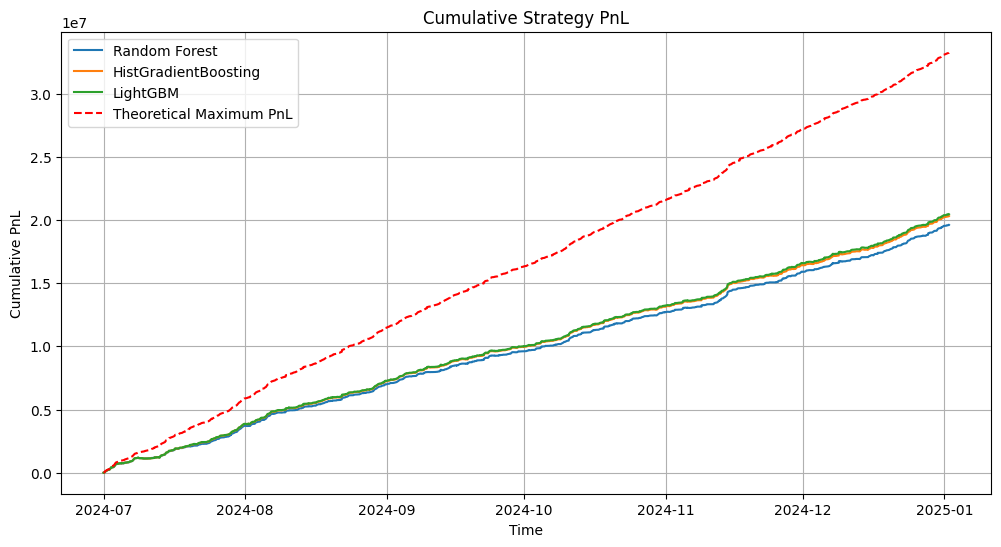

In [223]:
plt.figure(figsize=(12,6))

plt.plot(X_test.index, rf_strategy_results["pnl_vector"].cumsum(), label="Random Forest")
plt.plot(X_test.index, hgb_strategy_results["pnl_vector"].cumsum(), label="HistGradientBoosting")
plt.plot(X_test.index, lgbm_strategy_results["pnl_vector"].cumsum(), label="LightGBM")
plt.plot(X_test.index, perfect_pnl_vector.cumsum(), label = "Theoretical Maximum PnL", color = "red", linestyle = "--")
plt.title("Cumulative Strategy PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)

plt.show()

# In here, we will just download useful thing to our local machine 

In [228]:
np.save("results/numpy_objects/hgb_pnl_vector.npy", hgb_strategy_results["pnl_vector"])

In [229]:
np.save("results/numpy_objects/lgbm_pnl_vector.npy", lgbm_strategy_results["pnl_vector"])

In [230]:
np.save("results/numpy_objects/rf_pnl_vector.npy", rf_strategy_results["pnl_vector"])

In [231]:
np.save("results/numpy_objects/perfect_pnl_vector.npy", perfect_pnl_vector)

In [232]:
X_test_index = X_test.index

In [233]:
np.save("results/numpy_objects/X_test_index.npy", X_test_index)

# Saving the csv file in order to get processed by Streamlit

In [234]:
hgb_importance_avg.to_csv("results/tables/hgb_importance_avg.csv")

In [235]:
lgbm_importance_avg.to_csv("results/tables/lgbm_importance_avg.csv")

In [236]:
rf_importance_avg.to_csv("results/tables/rf_importance_avg.csv")

In [238]:
model_pred_perf.to_csv("results/tables/model_prediction_performance")

In [239]:
trading_perf.to_csv("results/tables/trading_perfomance.csv")